In [28]:
import random
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


In [29]:

def generate_random_tree(prefix, node_type, target_size, target_depth):
    G = nx.DiGraph()
    root_id = f"{prefix}_0"
    G.add_node(root_id, type=node_type, level=0)
    all_nodes = [root_id]
    
    # Force a path to target_depth
    current_node = root_id
    for d in range(1, target_depth + 1):
        new_id = f"{prefix}_{len(all_nodes)}"
        G.add_node(new_id, type=node_type, level=d)
        G.add_edge(new_id, current_node, relation='hierarchy')
        all_nodes.append(new_id)
        current_node = new_id

    # Expand randomly
    while len(all_nodes) < target_size:
        parent = random.choice(all_nodes)
        if G.nodes[parent]['level'] < target_depth:
            new_id = f"{prefix}_{len(all_nodes)}"
            new_level = G.nodes[parent]['level'] + 1
            G.add_node(new_id, type=node_type, level=new_level)
            G.add_edge(new_id, parent, relation='hierarchy')
            all_nodes.append(new_id)
    return G, all_nodes

def generate_se_dataset_with_outliers(
    req_size=100, req_depth=3,
    func_size=150, func_depth=4,
    comp_size=150, comp_depth=4,
    p_illegal_satisfy=0.05, 
    p_missing_satisfy=0.1
):
    # 1. Generate Domain Trees
    req_tree, req_nodes = generate_random_tree("REQ", "requirement", req_size, req_depth)
    func_tree, func_nodes = generate_random_tree("FUNC", "function", func_size, func_depth)
    log_tree, log_nodes = generate_random_tree("COMP", "component", comp_size, comp_depth)
    G = nx.compose_all([req_tree, func_tree, log_tree])
    
    # 2. Random Allocations
    allocations = {node: [] for node in func_nodes + log_nodes}
    for req in req_nodes:
        target_f, target_c = random.choice(func_nodes), random.choice(log_nodes)
        # Default all allocations to "outlier=False"; logic will flip them if unsatisfied
        G.add_edge(req, target_f, relation='allocated_to', outlier=False)
        G.add_edge(req, target_c, relation='allocated_to', outlier=False)
        allocations[target_f].append(req)
        allocations[target_c].append(req)

    # 3. Satisfaction Logic + Outlier Insertion
    for node in func_nodes + log_nodes:
        n_type = G.nodes[node]['type']
        parents = [p for p in G.successors(node) if G.nodes[p]['type'] == n_type]
        
        # Outlier Type 1: Allocated req NOT satisfied by child (Missing Satisfy)
        for parent in parents:
            for req in allocations.get(parent, []):
                if random.random() > p_missing_satisfy:
                    G.add_edge(node, req, relation='satisfies', outlier=False)
                else:
                    # Flag the 'allocated_to' link as an outlier because it lacks a satisfy link
                    G[req][parent]['outlier'] = True

        # Outlier Type 2: Satisfies req NOT allocated to parent (Illegal Satisfy)
        if random.random() < p_illegal_satisfy:
            p_reqs_set = {r for p in parents for r in allocations.get(p, [])}
            illegal_pool = list(set(req_nodes) - p_reqs_set)
            if illegal_pool:
                wrong_req = random.choice(illegal_pool)
                G.add_edge(node, wrong_req, relation='satisfies', outlier=True)
                        
    return G

In [21]:
def plot_se_system_v2(G):
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
    
    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else 
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]

    # Edge filtering
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']
    
    # Type 1: Orange allocations (missing satisfaction)
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]
    
    # Type 2: Magenta satisfaction (illegal link)
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='#CCCCCC', alpha=0.3, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2.5)
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.2)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Req/Func/Comp', markerfacecolor='gray', markersize=10),
        Line2D([0], [0], color='orange', lw=2.5, label='Type 1: Unsatisfied Allocation'),
        Line2D([0], [0], color='magenta', lw=2.5, label='Type 2: Illegal Satisfaction'),
        Line2D([0], [0], color='red', lw=1, alpha=0.3, label='Valid Allocation'),
        Line2D([0], [0], color='green', lw=1, alpha=0.3, label='Valid Satisfaction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title("Systems Engineering Data: Outlier Analysis")
    plt.axis('off')
    plt.show()

In [9]:
def plot_se_clustered_by_domain_and_tier(G):
    plt.figure(figsize=(16, 10))
    
    # 1. Define Cluster spacing
    # x: Domain mapping (Requirements=0, Functions=5, Components=10)
    # y: Tier mapping (Level 0 at top, increasing levels going down)
    domain_x = {'requirement': 0, 'function': 5, 'component': 10}
    
    # Use a dictionary to keep track of how many nodes are at each (domain, level) 
    # to spread them out horizontally within their cluster
    pos = {}
    counts = {}
    
    for node, data in G.nodes(data=True):
        d_type = data['type']
        level = data['level']
        
        # Initialize sub-cluster offsets
        cluster_key = (d_type, level)
        counts[cluster_key] = counts.get(cluster_key, 0) + 1
        
        # Position = (Base Domain X + minor jitter, -Level Y)
        # Jitter prevents nodes at the same tier from overlapping
        jitter = (counts[cluster_key] % 10) * 0.2 
        pos[node] = (domain_x[d_type] + jitter, -level)

    # 2. Extract Edges (keeping outlier logic from before)
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # 3. Draw with the new clustered positions
    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else 
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]
    
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='gray', alpha=0.2, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2, label="Unsatisfied")
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2, label="Illegal")

    # Add column labels for clarity
    plt.text(0, 0.5, "REQUIREMENTS", fontweight='bold', ha='center')
    plt.text(5, 0.5, "FUNCTIONS", fontweight='bold', ha='center')
    plt.text(10, 0.5, "COMPONENTS", fontweight='bold', ha='center')

    plt.title("Clustered Systems Engineering Graph (Domain vs Tier)")
    plt.axis('off')
    plt.show()

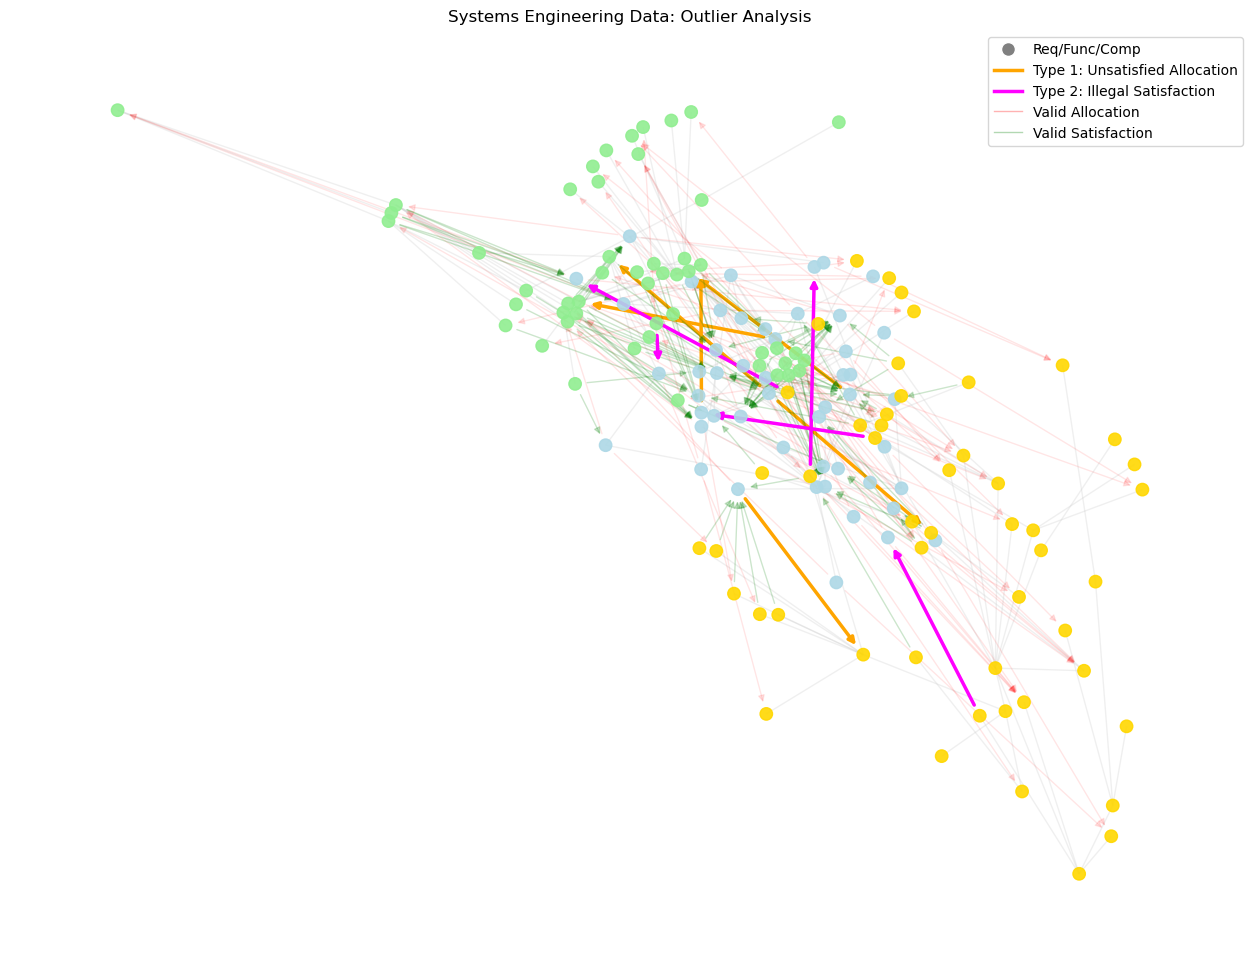

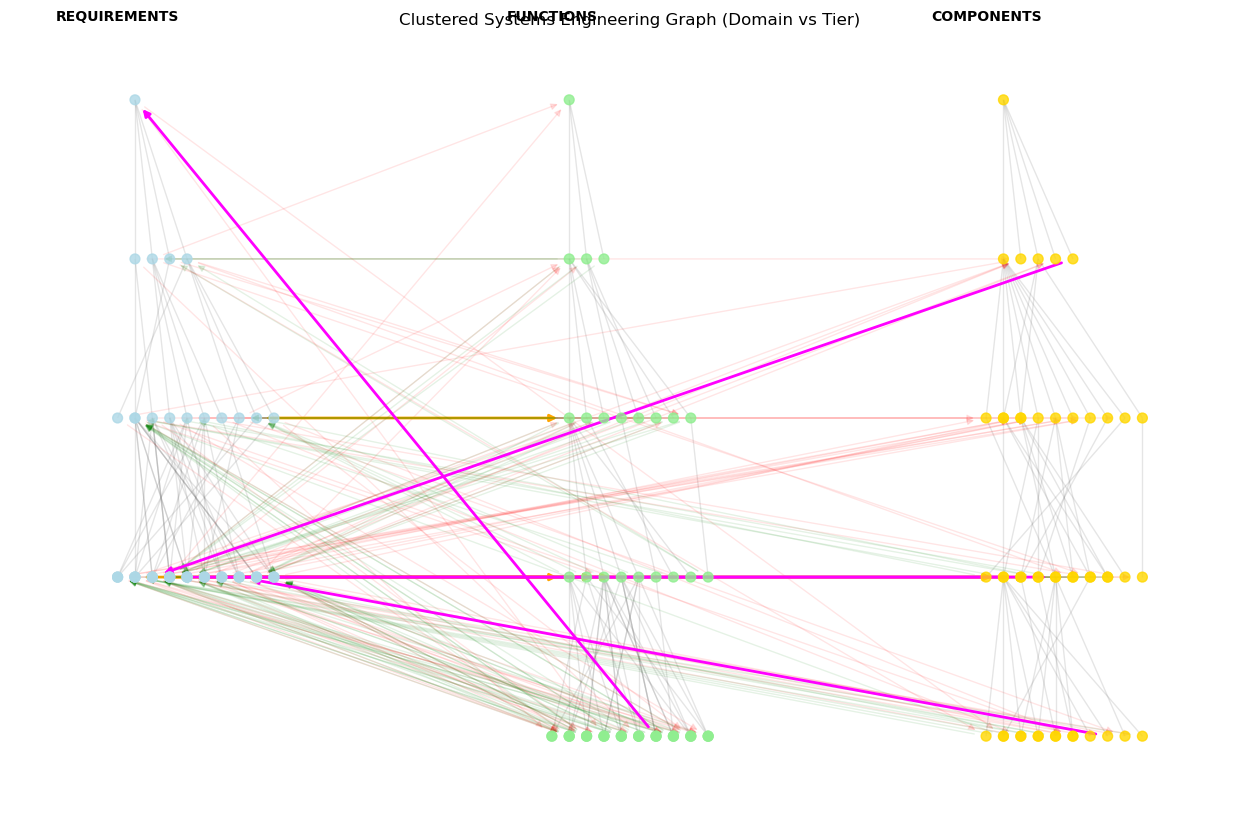

In [17]:
# Generate and Plot
g = generate_se_dataset_with_outliers(req_size=50, req_depth=3,
    func_size=50, func_depth=4,
    comp_size=50, comp_depth=4,p_illegal_satisfy=0.05, p_missing_satisfy=0.1)
plot_se_system_v2(g)
plot_se_clustered_by_domain_and_tier(g)

In [18]:
def convert_to_pyg_data(G):
    # 1. Map string node IDs to integer indices
    nodes = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    # 2. Encode Node Features (X)
    # We'll use One-Hot encoding for the 3 types: [Req, Func, Comp]
    type_map = {'requirement': 0, 'function': 1, 'component': 2}
    x_list = []
    for node in nodes:
        attr = G.nodes[node]
        # Feature vector: [Is_Req, Is_Func, Is_Comp, Normalized_Level]
        vec = [0.0, 0.0, 0.0, attr['level'] / 5.0] 
        vec[type_map[attr['type']]] = 1.0
        x_list.append(vec)
    x = torch.tensor(x_list, dtype=torch.float)

    # 3. Encode Edges (edge_index) and Relationship Types
    edge_index_list = []
    edge_attr_list = []
    y_list = [] # Our target labels: 1 for outlier, 0 for valid
    
    rel_map = {'hierarchy': 0, 'allocated_to': 1, 'satisfies': 2}
    
    for u, v, data in G.edges(data=True):
        edge_index_list.append([node_to_idx[u], node_to_idx[v]])
        
        # Edge Feature: One-hot relationship type
        rel_vec = [0.0, 0.0, 0.0]
        rel_vec[rel_map[data['relation']]] = 1.0
        edge_attr_list.append(rel_vec)
        
        # Label: Is this an outlier?
        y_list.append(1 if data.get('outlier', False) else 0)

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)
    y = torch.tensor(y_list, dtype=torch.float) # Or long if using CrossEntropy

    # 4. Create PyG Data object
    pyg_data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    
    return pyg_data, node_to_idx

# Convert our graph
pyg_dataset, mapping = convert_to_pyg_data(g)

print("PyG Data Summary:")
print(f"Number of nodes: {pyg_dataset.num_nodes}")
print(f"Number of edges: {pyg_dataset.num_edges}")
print(f"Feature size: {pyg_dataset.num_node_features}")
print(f"Outlier labels count: {int(pyg_dataset.y.sum())}")

PyG Data Summary:
Number of nodes: 150
Number of edges: 363
Feature size: 4
Outlier labels count: 11


In [22]:
class SEOutlierDetector(torch.nn.Module):
    def __init__(self, node_features, edge_features, hidden_channels):
        super(SEOutlierDetector, self).__init__()
        
        # GAT Layer 1: Learns local neighborhood relationships
        self.conv1 = GATv2Conv(node_features, hidden_channels, heads=4, edge_dim=edge_features)
        
        # GAT Layer 2: Refines embeddings (concatenates 4 heads from layer 1)
        self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=1, edge_dim=edge_features)

        # Edge Classifier: Takes two node embeddings and predicts the outlier label
        # We multiply by 2 because we concatenate the embeddings of the two nodes forming the edge
        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, 1) # Binary classification: 0 (Valid) or 1 (Outlier)
        )

    def forward(self, x, edge_index, edge_attr):
        # 1. Generate Node Embeddings
        h = self.conv1(x, edge_index, edge_attr)
        h = F.elu(h)
        h = self.conv2(h, edge_index, edge_attr)

        # 2. Edge Classification
        # Extract features for the source (u) and target (v) nodes of every edge
        row, col = edge_index
        edge_feat = torch.cat([h[row], h[col]], dim=-1)
        
        return self.edge_classifier(edge_feat).squeeze()

# Initialize Model
model = SEOutlierDetector(
    node_features=pyg_dataset.num_node_features, 
    edge_features=pyg_dataset.edge_attr.size(1), 
    hidden_channels=32
)

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# Calculate a weight for the positive class (outliers) to handle imbalance
pos_weight = (pyg_dataset.y == 0).sum() / (pyg_dataset.y == 1).sum()
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train():
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(pyg_dataset.x, pyg_dataset.edge_index, pyg_dataset.edge_attr)
    
    # Only train on 'satisfies' and 'allocated_to' links (where outliers exist)
    # You can also train on all links if preferred
    loss = criterion(out, pyg_dataset.y)
    
    loss.backward()
    optimizer.step()
    return loss.item()

# Simple loop
for epoch in range(1001):
    loss = train()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")

Epoch 000, Loss: 0.3489
Epoch 100, Loss: 0.2772
Epoch 200, Loss: 0.1849
Epoch 300, Loss: 0.1334
Epoch 400, Loss: 0.1284
Epoch 500, Loss: 0.1269
Epoch 600, Loss: 0.1229
Epoch 700, Loss: 0.8255
Epoch 800, Loss: 0.4890
Epoch 900, Loss: 0.4192
Epoch 1000, Loss: 0.3840


--- Overall Performance ---
              precision    recall  f1-score   support

       Valid       1.00      0.88      0.93       352
     Outlier       0.20      1.00      0.33        11

    accuracy                           0.88       363
   macro avg       0.60      0.94      0.63       363
weighted avg       0.98      0.88      0.92       363



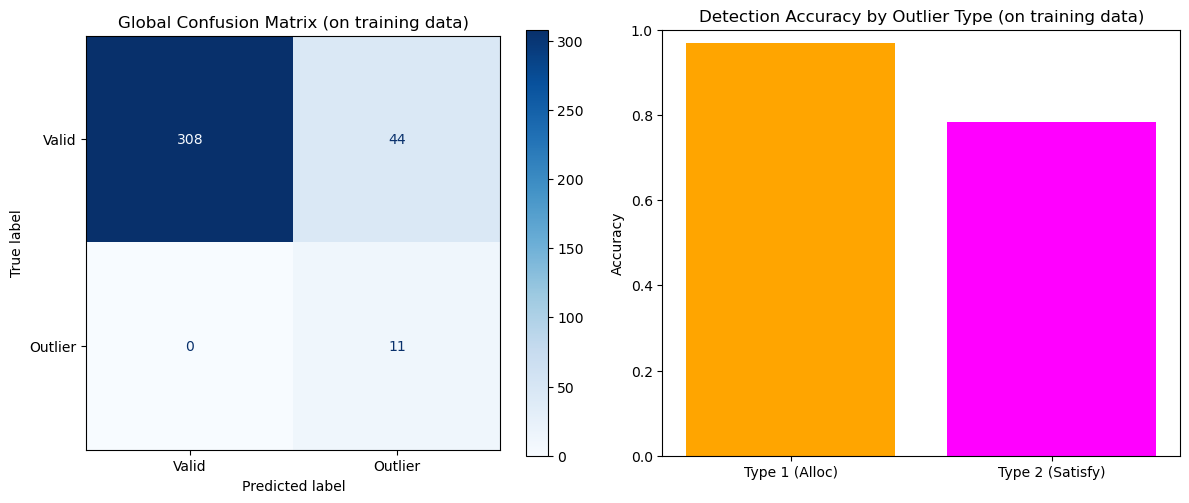

In [40]:
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        # Get raw model outputs (logits) and convert to probabilities
        logits = model(data.x, data.edge_index, data.edge_attr)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        y_true = data.y.cpu().numpy()
        y_pred = preds.cpu().numpy()

    # 1. Standard Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Slice results by Outlier Type
    # Find indices for specific relationship types
    # [0, 1, 0] = Allocated_to (Type 1 Potential)
    # [0, 0, 1] = Satisfies (Type 2 Potential)
    is_alloc = (data.edge_attr[:, 1] == 1).cpu().numpy()
    is_satisfy = (data.edge_attr[:, 2] == 1).cpu().numpy()

    print("--- Overall Performance ---")
    print(classification_report(y_true, y_pred, target_names=['Valid', 'Outlier']))

    # 3. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Global Confusion Matrix
    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax[0], cmap='Blues')
    ax[0].set_title("Global Confusion Matrix (on training data)")

    # Specific Breakdown
    type1_acc = (y_true[is_alloc] == y_pred[is_alloc]).mean() if any(is_alloc) else 0
    type2_acc = (y_true[is_satisfy] == y_pred[is_satisfy]).mean() if any(is_satisfy) else 0
    
    ax[1].bar(['Type 1 (Alloc)', 'Type 2 (Satisfy)'], [type1_acc, type2_acc], color=['orange', 'magenta'])
    ax[1].set_ylim(0, 1)
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Detection Accuracy by Outlier Type (on training data)")
    
    plt.tight_layout()
    plt.show()

# Run Evaluation
evaluate_model(model, pyg_dataset)


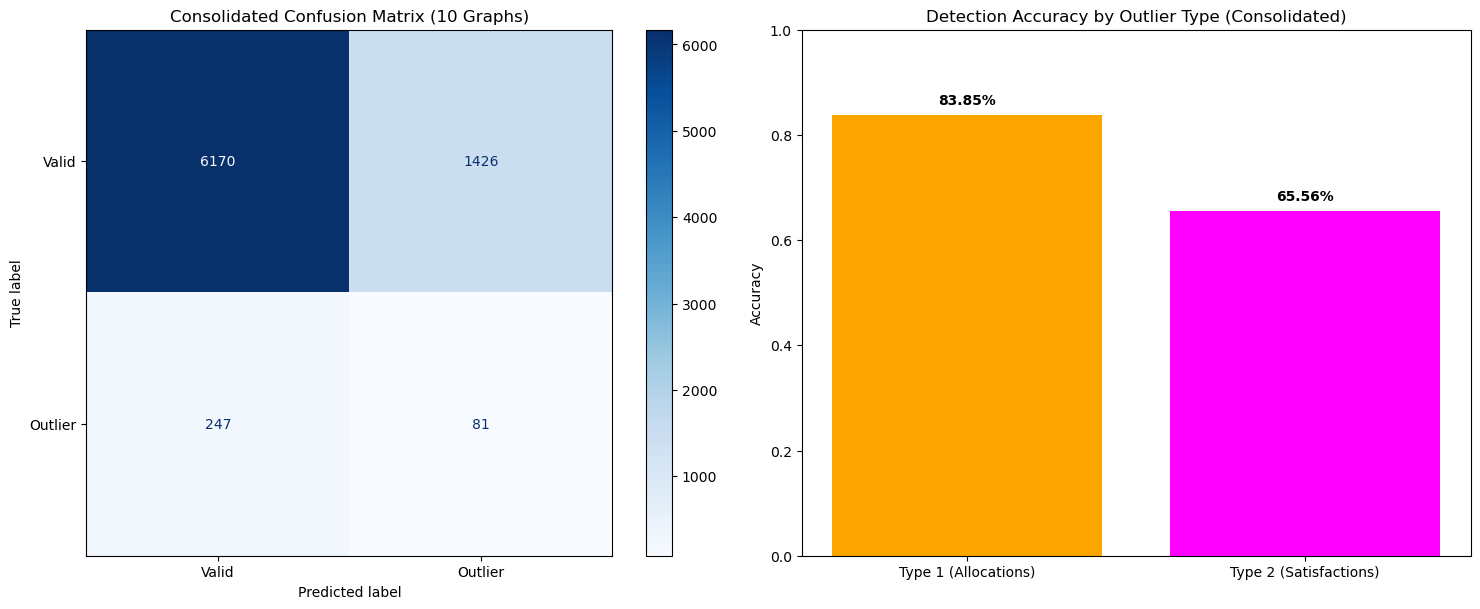

In [37]:
def test_gnn_consolidated(model, num_test_graphs=10):
    model.eval()
    
    # Storage for overall results
    all_y_true = []
    all_y_pred = []
    
    # Storage for type-specific accuracy
    type1_results = {'true': [], 'pred': []} # Allocations
    type2_results = {'true': [], 'pred': []} # Satisfactions

    for i in range(num_test_graphs):
        # 1. Generate new unseen graph
        g_test = generate_se_dataset_with_outliers()
        data_test, _ = convert_to_pyg_data(g_test)
        
        with torch.no_grad():
            logits = model(data_test.x, data_test.edge_index, data_test.edge_attr)
            preds = (torch.sigmoid(logits) > 0.5).float()
            
        all_y_true.append(data_test.y)
        all_y_pred.append(preds)
        
        # 2. Slice results by Outlier Type for this specific graph
        # Index 1 = Allocation (Type 1), Index 2 = Satisfaction (Type 2)
        is_alloc = data_test.edge_attr[:, 1] == 1
        is_satisfy = data_test.edge_attr[:, 2] == 1
        
        type1_results['true'].append(data_test.y[is_alloc])
        type1_results['pred'].append(preds[is_alloc])
        type2_results['true'].append(data_test.y[is_satisfy])
        type2_results['pred'].append(preds[is_satisfy])

    # Concatenate all test data
    y_true_final = torch.cat(all_y_true).cpu().numpy()
    y_pred_final = torch.cat(all_y_pred).cpu().numpy()
    
    # 3. Calculate accuracies for the two outlier types
    t1_true = torch.cat(type1_results['true']).cpu().numpy()
    t1_pred = torch.cat(type1_results['pred']).cpu().numpy()
    t2_true = torch.cat(type2_results['true']).cpu().numpy()
    t2_pred = torch.cat(type2_results['pred']).cpu().numpy()
    
    t1_acc = (t1_true == t1_pred).mean()
    t2_acc = (t2_true == t2_pred).mean()

    # 4. Final Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Consolidated Confusion Matrix
    cm = confusion_matrix(y_true_final, y_pred_final)
    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax1, cmap='Blues')
    ax1.set_title(f"Consolidated Confusion Matrix ({num_test_graphs} Graphs)")

    # Detection Accuracy bar chart
    ax2.bar(['Type 1 (Allocations)', 'Type 2 (Satisfactions)'], [t1_acc, t2_acc], color=['orange', 'magenta'])
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Detection Accuracy by Outlier Type (Consolidated)")
    for i, v in enumerate([t1_acc, t2_acc]):
        ax2.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the consolidated test
test_gnn_consolidated(model, num_test_graphs=10)